# 1 Import

In [ ]:
#  UNITÉS (définitives, validées sur les données brutes) :
#  ─────────────────────────────────────────────────────
#  yield              : % (ex: 1.396 pour 1.396%)
#  price              : price points base 100 (ex: 104.835)
#  dv01 source        : pour notional=1  (ex: 0.000907 pour Bund 10 ans)
#  dv01 réel          : pour notional=100 = dv01_source × 100 (ex: 0.0907)
#  dy_bp              : bp  (= diff(yield) × 100, car yield en %)
#  pnl_carry          : décimal de notional  (Δaccrued/100 + coupons/100)
#  pnl_yield          : décimal de notional  (= -dv01_source × dy_bp)
#  pnl_total_unit     : décimal de notional  (= pnl_yield + pnl_carry)
#  carry_bp_equiv     : bp  (= pnl_carry / dv01_source)
#  ret_total_per_dv01 : bp  (= -dy_bp + carry_bp_equiv)
#  bid_offer_yield    : bp  (= q25_spread_yield × 100)
#
#  VÉRIFICATION COHÉRENCE :
#    pnl_total_unit ≈ ret_total_per_dv01 × dv01_source
#    ex: -2 bp × 0.000907 = -0.00181 décimal ✅
#    carry annualisé : carry_bp_equiv × 252 ≈ 10-50 bp/an ✅
# =============================================================================

import numpy as np
import pandas as pd
import warnings
import re
from functools import lru_cache

import QuantLib as ql

warnings.filterwarnings("ignore")

# =============================================================================
#  0. CONSTANTES
# =============================================================================

COUNTRIES_UNIVERSE = ["FR", "DE", "IT"]

COUNTRY_DEFAULT_FREQ_MAP = {
    "FR": 1, "DE": 1, "IT": 2, 
}

# DV01 de référence FIXE pour normalisation portefeuille
# = dv01_source × 100 d'un bond 10 ans ≈ 0.000907 × 100 = 0.0907
DV01_REF = 0.09   # notional 100

# Clip des sauts de benchmark (changement d'ISIN de référence dans un bucket)
CLIP_RET_BP = 20  # bp

# Bid/offer multiplicateurs pour composés
BID_OFFER_MULTIPLIER = {
    "spread": 0.5,
    "curve":  0.4,
    "fly":    0.25,
    "box":    0.375,
}

# Filtre qualité ISINs
MIN_OBS_PER_ISIN = 20
MAX_DAILY_CARRY  = 0.005   # 0.5% de notional par jour = aberrant


# =============================================================================
#  1. CALENDRIERS QUANTLIB
# =============================================================================



# 2 Pipeline des données

## 2.1 Carry par ISIN (QuantLib)

In [ ]:
# =============================================================================
#  1. CARRY PAR ISIN (QuantLib)
# =============================================================================
def get_calendar(country_iso: str) -> ql.Calendar:
    return {
        "FR": ql.France(),
        "DE": ql.Germany(),
        "IT": ql.Italy(),
        "SP": ql.Spain(),
        "PT": ql.Portugal(),
        "BE": ql.Belgium(),
        "AT": ql.Austria(),
        "NL": ql.Netherlands(),
    }.get(country_iso, ql.TARGET())

@lru_cache(maxsize=None)
def _build_bond(issue_date, maturity_date, coupon_pct, freq, country_iso):
    """
    Construit un FixedRateBond QuantLib.
    coupon_pct : en % (ex: 1.5 pour 1.5%) — tel que dans metadata_bonds.csv
    Retourne (bond, [(ql.Date, amount), ...])
    """
    cal      = get_calendar(country_iso)
    daycount = ql.ActualActual(ql.ActualActual.ISMA)
    freq_map = {1: ql.Annual, 2: ql.Semiannual, 4: ql.Quarterly}
    frequency = freq_map.get(int(freq), ql.Semiannual)

    issue_ql = ql.Date(issue_date.day, issue_date.month, issue_date.year)
    mat_ql   = ql.Date(maturity_date.day, maturity_date.month, maturity_date.year)

    schedule = ql.Schedule(
        issue_ql, mat_ql,
        ql.Period(frequency), cal,
        ql.Following, ql.Following,
        ql.DateGeneration.Backward, False,
    )

    # QuantLib attend un taux décimal : coupon_pct / 100
    bond = ql.FixedRateBond(0, 100.0, schedule, [float(coupon_pct) / 100.0], daycount)
    cfs  = sorted(
        [(cf.date(), float(cf.amount()))
         for cf in bond.cashflows() if isinstance(cf, ql.Coupon)],
        key=lambda x: x[0]
    )
    return bond, cfs


def _compute_carry_for_isin(df_isin: pd.DataFrame) -> pd.DataFrame:
    """
    pnl_carry journalier en décimal de notional :
      = (Δaccrued + coupons payés dans (t-1, t]) / 100

    Fallback si métadonnées manquantes :
      ≈ (price/100) × (yield/100) / 252
    """
    df = df_isin.sort_values("time_stamp").copy()

    needs = ["issue_date", "maturity_date", "coupon", "cpn_freq", "country_iso"]
    if any(c not in df.columns or df[c].isna().all() for c in needs):
        df["pnl_carry"] = (df["price"] / 100.0) * (df["yield"] / 100.0) / 252.0
        return df

    issue_date    = df["issue_date"].iloc[0]
    maturity_date = df["maturity_date"].iloc[0]
    coupon_pct    = float(df["coupon"].iloc[0])   # en %, ex: 1.5
    freq          = int(df["cpn_freq"].iloc[0])
    country_iso   = df["country_iso"].iloc[0]

    try:
        bond, cfs = _build_bond(issue_date, maturity_date, coupon_pct, freq, country_iso)
    except Exception as e:
        warnings.warn(f"QuantLib error: {e}")
        df["pnl_carry"] = (df["price"] / 100.0) * (df["yield"] / 100.0) / 252.0
        return df

    cf_dates     = [d for d, _ in cfs]
    cf_amts      = [a for _, a in cfs]
    carry        = np.zeros(len(df), dtype=float)
    prev_ql      = None
    accrued_prev = None
    k            = 0

    for i, ts in enumerate(df["time_stamp"].tolist()):
        d       = ql.Date(ts.day, ts.month, ts.year)
        accrued = float(bond.accruedAmount(d))   # price points sur base 100

        if prev_ql is None:
            carry[i] = 0.0
            while k < len(cf_dates) and cf_dates[k] <= d:
                k += 1
        else:
            coupons = 0.0
            while k < len(cf_dates) and cf_dates[k] <= d:
                coupons += cf_amts[k]
                k += 1
            # price points → décimal de notional
            carry[i] = ((accrued - accrued_prev) + coupons) / 100.0

        prev_ql      = d
        accrued_prev = accrued

    df["pnl_carry"] = carry
    return df

## 2.2 Chargement et nettoyage

In [ ]:
# =============================================================================
#  2. CHARGEMENT & NETTOYAGE
# =============================================================================

def load_and_clean_raw(
    path_mids: str = "data/benchmark_mids_cs.csv",
    path_meta: str = "data/metadata_bonds.csv",
) -> pd.DataFrame:

    print("  Chargement benchmark_mids_cs...")
    data = pd.read_csv(path_mids)

    # Timestamp avec timezone → date pure
    data["time_stamp"] = pd.to_datetime(data["time_stamp"], utc=True).dt.tz_localize(None)

    # Filtrer sur l'univers
    data = data[data["country_iso"].isin(COUNTRIES_UNIVERSE)].copy()

    # Dédoublonnage : dernière observation par jour par ISIN
    data = (
        data
        .groupby(["isin", data["time_stamp"].dt.date], as_index=False)
        .last()
    )
    data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
    data = data.sort_values(["isin", "time_stamp"]).reset_index(drop=True)

    # mat_cat en string pour noms de produits
    data["mat_cat"] = data["mat_cat"].astype(str)

    # Supprimer lignes sans prix/yield/dv01
    data = data.dropna(subset=["price", "yield", "dv01"])

    # Métadonnées
    print("  Chargement metadata_bonds...")
    meta = pd.read_csv(path_meta)
    meta["issue_date"]    = pd.to_datetime(meta["issue_date"],    errors="coerce")
    meta["maturity_date"] = pd.to_datetime(meta["maturity_date"], errors="coerce")
    meta["coupon"]        = pd.to_numeric(meta["coupon"],         errors="coerce")  # en %
    meta["cpn_freq"]      = pd.to_numeric(meta["cpn_freq"],       errors="coerce")
    meta = meta[["isin","issue_date","maturity_date","coupon","cpn_freq"]].drop_duplicates("isin")

    data = data.merge(meta, on="isin", how="left")

    # Fréquence coupon par défaut
    data["cpn_freq"] = (
        data["cpn_freq"]
        .fillna(data["country_iso"].map(COUNTRY_DEFAULT_FREQ_MAP))
        .fillna(2)
        .astype(int)
    )

    print(f"  Après nettoyage : {data['isin'].nunique()} ISINs, "
          f"{data['time_stamp'].nunique()} dates, {len(data):,} lignes")
    return data

## 2.3 Calcul returns

In [ ]:
# =============================================================================
#  4. CALCUL DES RETURNS
# =============================================================================

def compute_returns(data: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute :
      dy_bp              : diff(yield) × 100  [bp]
      pnl_carry          : QuantLib            [décimal]
      pnl_yield          : -dv01_source × dy_bp [décimal]
      pnl_total_unit     : pnl_yield + pnl_carry [décimal]
      carry_bp_equiv     : pnl_carry / dv01_source [bp]
      ret_total_per_dv01 : -dy_bp + carry_bp_equiv [bp]
    """
    # dy_bp : yield en % → diff en % → ×100 pour bp
    data["dy_bp"] = data.groupby("isin")["yield"].diff() * 100

    # Carry QuantLib
    print("  Calcul carry QuantLib...")
    try:
        data = data.groupby("isin", group_keys=False).apply(
            _compute_carry_for_isin, include_groups=True
        )
    except TypeError:
        data = data.groupby("isin", group_keys=False).apply(_compute_carry_for_isin)

    # Filtre qualité ISINs
    valid = (
        data.groupby("isin")
        .filter(lambda x:
            len(x) >= MIN_OBS_PER_ISIN
            and x["pnl_carry"].abs().max() < MAX_DAILY_CARRY
        )["isin"].unique()
    )
    n_before = data["isin"].nunique()
    data = data[data["isin"].isin(valid)]
    print(f"  Filtre qualité : {n_before - data['isin'].nunique()} ISINs retirés")

    # pnl_yield = -dv01_source × dy_bp  [décimal]
    # cohérence : 0.000907 × 2 bp = 0.00181 décimal ✅
    data["pnl_yield"]      = -data["dv01"] * data["dy_bp"]
    data["pnl_total_unit"] =  data["pnl_yield"] + data["pnl_carry"]

    # carry_bp_equiv = pnl_carry / dv01_source  [bp]
    # cohérence : 0.0000595 / 0.000907 = 0.066 bp/jour × 252 = 16 bp/an ✅
    eps = data["dv01"].quantile(0.01)
    data["carry_bp_equiv"] = np.where(
        np.abs(data["dv01"]) > eps,
        data["pnl_carry"] / data["dv01"],
        0.0,
    )

    # ret_total_per_dv01 = -dy_bp + carry_bp_equiv  [bp]
    data["ret_total_per_dv01"] = -data["dy_bp"] + data["carry_bp_equiv"]

    # Sanity checks
    med_dy    = data["dy_bp"].abs().median()
    med_carry = data["carry_bp_equiv"].abs().median()
    med_ret   = data["ret_total_per_dv01"].abs().median()
    print(f"  dy_bp              médiane abs : {med_dy:.4f} bp/jour  (attendu 0.5–5)")
    print(f"  carry_bp_equiv     médiane abs : {med_carry:.6f} bp/jour  (attendu 0.01–0.2)")
    print(f"  ret_total_per_dv01 médiane abs : {med_ret:.4f} bp/jour  (attendu 0.5–5)")

    # Vérification cohérence pnl vs ret×dv01
    check = (data["pnl_total_unit"] / (data["ret_total_per_dv01"] * data["dv01"])).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    print(f"  Ratio pnl / (ret×dv01) médian : {check.median():.3f}  (attendu ~1.0)")

    return data

## 2.4 Format produit

In [ ]:
# =============================================================================
#  5. FORMAT PRODUIT
# =============================================================================

def build_data_completed(data: pd.DataFrame) -> pd.DataFrame:
    """
    ISIN → produit (country_iso_mat_cat), médiane par bucket.
    """
    data = data.copy()
    data["product"] = data["country_iso"] + "_" + data["mat_cat"]

    data_completed = (
        data
        .groupby(["time_stamp", "product"])
        .agg(
            ret_total_per_dv01 = ("ret_total_per_dv01", "median"),
            pnl_total_unit     = ("pnl_total_unit",     "median"),
            dv01               = ("dv01",               "median"),
            carry_bp_equiv     = ("carry_bp_equiv",     "median"),
            maturity_date      = ("maturity_date",      "min"),
        )
        .reset_index()
    )
    data_completed["time_stamp"]    = pd.to_datetime(data_completed["time_stamp"])
    data_completed["maturity_date"] = pd.to_datetime(data_completed["maturity_date"])

    # Clip sauts de benchmark
    n_clip = (data_completed["ret_total_per_dv01"].abs() > CLIP_RET_BP).sum()
    if n_clip > 0:
        print(f"  Clip sauts ISIN : {n_clip} valeurs |ret| > {CLIP_RET_BP} bp")
    data_completed["ret_total_per_dv01"] = (
        data_completed["ret_total_per_dv01"].clip(-CLIP_RET_BP, CLIP_RET_BP)
    )

    print(f"  data_completed : {data_completed['product'].nunique()} produits, "
          f"{data_completed['time_stamp'].nunique()} dates, "
          f"{len(data_completed):,} lignes")
    return data_completed

## 2.5 Bid/offer 

In [ ]:
# =============================================================================
#  6. BID/OFFER
# =============================================================================

def load_bidoffer(path_bo: str = "data/bid_offer_CS.csv") -> pd.Series:
    """
    bid/offer en bp pour les bonds simples de l'univers FR/DE/IT.
    q25_spread_yield est en décimal → ×100 pour bp.
    """
    bo = pd.read_csv(path_bo)
    bo["mat_cat"] = bo["mat_cat"].astype(str)
    bo = bo[bo["country_iso"].isin(COUNTRIES_UNIVERSE)].copy()
    bo["product"] = bo["country_iso"] + "_" + bo["mat_cat"]

    bond_bidoffer = (
        bo.groupby("product")["q25_spread_yield"]
        .median()
        .rename("bid_offer_yield")
        * 100   # décimal → bp
    )

    print(f"  bid_offer (bp) :\n{bond_bidoffer.sort_index().to_string()}")
    return bond_bidoffer

## 2.6 Spread Curve 

In [ ]:
# =============================================================================
#  7. ADD_SPREAD_CURVE
# =============================================================================

def add_spread_curve(
    data: pd.DataFrame,
    value_col: str       = "pnl_total_unit",
    bond_bidoffer_yield  = None,
    bid_offer_multiplier = None,
) -> pd.DataFrame:
    """
    Construit bonds + spreads pays + spreads courbe + flies + slopes.
    Propage bid_offer_yield [bp], maturity_date, carry_bp_equiv [bp].
    """
    if bid_offer_multiplier is None:
        bid_offer_multiplier = BID_OFFER_MULTIPLIER

    df       = data.copy()
    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    def sort_mats(mats):
        try:    return sorted(mats, key=lambda x: float(x))
        except: return sorted(mats)

    maturities = sort_mats({p.split("_")[1] for p in products})

    product_type     = {p: "bond" for p in products}
    bidoffer_product = {}
    maturity_product = {}
    carry_product    = {}

    wide = df.pivot(index="time_stamp", columns="product", values=value_col).sort_index()

    if bond_bidoffer_yield is not None:
        for p in wide.columns:
            if p in bond_bidoffer_yield.index:
                bidoffer_product[p] = float(bond_bidoffer_yield.loc[p])

    if "maturity_date" in df.columns:
        maturity_product = df.groupby("product")["maturity_date"].min().to_dict()

    if "carry_bp_equiv" in df.columns:
        carry_product = df.groupby("product")["carry_bp_equiv"].median().to_dict()

    def _min_mat(*prods):
        dates = [maturity_product[p] for p in prods if p in maturity_product]
        return min(dates) if dates else pd.NaT

    def _carry_composite(legs):
        total = 0.0
        for p, coef in legs:
            c = carry_product.get(p, np.nan)
            if np.isnan(c): return np.nan
            total += coef * c
        return total

    def _bo_composite(legs, mult_key):
        bos = [bidoffer_product.get(p, np.nan) for p, _ in legs]
        if not all(np.isfinite(b) for b in bos): return np.nan
        return np.mean(bos) * bid_offer_multiplier[mult_key]

    def _add(name, series, ptype, legs, bo_key):
        if name in wide.columns: return
        wide[name]             = series
        product_type[name]     = ptype
        maturity_product[name] = _min_mat(*[p for p, _ in legs])
        carry_product[name]    = _carry_composite(legs)
        if bond_bidoffer_yield is not None:
            bo = _bo_composite(legs, bo_key)
            if np.isfinite(bo): bidoffer_product[name] = bo

    # Spreads entre pays
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]
        for i in range(len(prods_mat)):
            for j in range(i+1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]
                _add(f"{c1}_{c2}_{mat}", wide[p1]-wide[p2],
                     "spread_country", [(p1,1.),(p2,-1.)], "spread")

    # Spreads de courbe
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c+"_")])
        for i in range(len(mats_c)):
            for j in range(i+1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"
                if p1 in wide.columns and p2 in wide.columns:
                    _add(f"{c}_{m1}_{m2}", wide[p1]-wide[p2],
                         "spread_curve", [(p1,1.),(p2,-1.)], "curve")

    # Butterflies
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c+"_")])
        for i in range(len(mats_c)-2):
            m1,m2,m3 = mats_c[i],mats_c[i+1],mats_c[i+2]
            p1,p2,p3 = f"{c}_{m1}",f"{c}_{m2}",f"{c}_{m3}"
            if all(p in wide.columns for p in (p1,p2,p3)):
                _add(f"{c}_fly_{m1}_{m2}_{m3}", wide[p1]-2*wide[p2]+wide[p3],
                     "butterfly_curve", [(p1,1.),(p2,-2.),(p3,1.)], "fly")

    # Slopes diff pays
    for il in range(len(maturities)-1):
        for ih in range(il+1, len(maturities)):
            ml, mh = maturities[il], maturities[ih]
            for i in range(len(countries)):
                for j in range(i+1, len(countries)):
                    c1,c2 = countries[i],countries[j]
                    p1l,p1h = f"{c1}_{ml}",f"{c1}_{mh}"
                    p2l,p2h = f"{c2}_{ml}",f"{c2}_{mh}"
                    if all(p in wide.columns for p in (p1l,p1h,p2l,p2h)):
                        _add(
                            f"{c1}_{c2}_slope_{ml}_{mh}",
                            (wide[p1h]-wide[p1l])-(wide[p2h]-wide[p2l]),
                            "slope_diff_country",
                            [(p1h,1.),(p1l,-1.),(p2h,-1.),(p2l,1.)],
                            "box"
                        )

    long = (
        wide.reset_index()
        .melt(id_vars="time_stamp", var_name="product", value_name=value_col)
    )
    long["type"]           = long["product"].map(product_type).fillna("unknown")
    long["maturity_date"]  = long["product"].map(maturity_product)
    long["carry_bp_equiv"] = long["product"].map(pd.Series(carry_product))
    if bond_bidoffer_yield is not None:
        long["bid_offer_yield"] = long["product"].map(pd.Series(bidoffer_product))

    return long

## 2.7 Main pipeline

In [ ]:
# =============================================================================
#  8. PIPELINE PRINCIPALE
# =============================================================================

def run_pipeline(
    path_mids: str  = "data/benchmark_mids_cs.csv",
    path_meta: str  = "data/metadata_bonds.csv",
    path_bo:   str  = "data/bid_offer_CS.csv",
    verbose:   bool = True,
) -> tuple:
    """
    Retourne (long, data_completed, DV01_REF, bond_bidoffer)

    long — colonnes garanties :
      time_stamp, product, type,
      ret_total_per_dv01  [bp],
      pnl_total_unit      [décimal de notional],
      dv01                [notional=1],
      carry_bp_equiv      [bp],
      maturity_date,
      bid_offer_yield     [bp]
    """
    if verbose: print("── 1. Chargement et nettoyage ──")
    data = load_and_clean_raw(path_mids, path_meta)

    if verbose: print("\n── 2. Calcul des returns ──")
    data = compute_returns(data)

    if verbose: print("\n── 3. Construction data_completed ──")
    data_completed = build_data_completed(data)

    if verbose: print("\n── 4. Chargement bid/offer ──")
    bond_bidoffer = load_bidoffer(path_bo)

    if verbose: print("\n── 5. add_spread_curve (pnl_total_unit) ──")
    long = add_spread_curve(data_completed, "pnl_total_unit", bond_bidoffer)

    if verbose: print("\n── 6. add_spread_curve (ret_total_per_dv01) ──")
    long2 = add_spread_curve(data_completed, "ret_total_per_dv01", bond_bidoffer)
    long["ret_total_per_dv01"] = long2["ret_total_per_dv01"]

    if verbose: print("\n── 7. DV01 médian par produit → merge dans long ──")
    long_dv01 = add_spread_curve(data_completed, "dv01")

    # Merge dv01 time-varying dans long (bonds simples ont dv01 daily, composés NaN)
    long = long.merge(
        long_dv01[["time_stamp", "product", "dv01"]],
        on=["time_stamp", "product"],
        how="left"
    )

    # Pour les composés, dv01 n'existe pas en tant que tel
    # → on utilise la médiane historique par produit comme proxy
    dv01_by_product = long_dv01.groupby("product")["dv01"].median()
    long["dv01"] = long["dv01"].fillna(long["product"].map(dv01_by_product))

    if verbose:
        print(f"\n── Résumé long ──")
        print(f"  {long['product'].nunique()} produits, {long['type'].value_counts().to_dict()}")
        print(f"\n  Ordres de grandeur par type :")
        for ptype in ["bond","spread_country","spread_curve","butterfly_curve","slope_diff_country"]:
            sub = long[long["type"] == ptype]
            ret_med  = sub["ret_total_per_dv01"].abs().median()
            bo_med   = sub["bid_offer_yield"].median() if "bid_offer_yield" in sub else np.nan
            carry_med = sub["carry_bp_equiv"].abs().median()
            print(f"    {ptype:30s} | ret={ret_med:.3f} bp | bo={bo_med:.3f} bp | carry={carry_med:.4f} bp")

    return long, data_completed, DV01_REF, bond_bidoffer

In [2]:
long, data_completed, dv01_ref, bond_bidoffer = run_pipeline()

── 1. Chargement et nettoyage ──
  Chargement benchmark_mids_cs...
  Chargement metadata_bonds...
  Après nettoyage : 166 ISINs, 2328 dates, 26,617 lignes

── 2. Calcul des returns ──
  Calcul carry QuantLib...
  Filtre qualité : 5 ISINs retirés
  dy_bp              médiane abs : 2.6500 bp/jour  (attendu 0.5–5)
  carry_bp_equiv     médiane abs : 0.075719 bp/jour  (attendu 0.01–0.2)
  ret_total_per_dv01 médiane abs : 2.6500 bp/jour  (attendu 0.5–5)
  Ratio pnl / (ret×dv01) médian : 1.000  (attendu ~1.0)

── 3. Construction data_completed ──
  Clip sauts ISIN : 241 valeurs |ret| > 20 bp
  data_completed : 15 produits, 2324 dates, 26,570 lignes

── 4. Chargement bid/offer ──
  bid_offer (bp) :
product
DE_10    0.3
DE_15    0.6
DE_2     1.5
DE_20    0.6
DE_3     2.3
DE_30    0.6
DE_5     0.7
DE_7     0.5
FR_1     1.0
FR_10    0.6
FR_15    2.0
FR_2     1.4
FR_20    1.7
FR_3     1.3
FR_30    1.7
FR_5     1.0
FR_50    4.4
FR_7     0.9
IT_10    0.2
IT_15    0.4
IT_2     1.1
IT_20    0.5
IT_3  

In [15]:
long.head()

,time_stamp,product,pnl_total_unit,type,maturity_date,carry_bp_equiv,bid_offer_yield,ret_total_per_dv01,dv01
0,2015-01-01,DE_10,NaN,bond,2026-08-15,0.012528,0.3,NaN,0.000957
1,2015-01-02,DE_10,NaN,bond,2026-08-15,0.012528,0.3,NaN,0.000957
2,2015-01-05,DE_10,NaN,bond,2026-08-15,0.012528,0.3,NaN,0.000957
3,2015-01-06,DE_10,NaN,bond,2026-08-15,0.012528,0.3,NaN,0.000957
4,2015-01-07,DE_10,NaN,bond,2026-08-15,0.012528,0.3,NaN,0.000957


# 3 Class Portfolio

In [16]:
"""
Classe Portfolio — version avec roll-down basé sur carry_bp_equiv
=================================================================

Correction fondamentale de update_positions :
  - AVANT : mu_old = mu_new * aging_ratio   (approximation sans fondement économique)
  - APRÈS  : mu_old = carry_old réel lu depuis carry_bp_equiv de la position tenue
             mu_new = carry_new réel lu depuis carry_bp_equiv du benchmark courant

  Décision de roll :
    U_keep    = carry_old - λ * σ²
    U_replace = carry_new - λ * σ² - TC_roll
    → on rolle si carry_new - carry_old > TC_roll   (net de coût)

  Pour les composés (spread, fly, slope) :
    carry = somme pondérée des carry_bp_equiv des jambes (avec les coefs ±1, ±2…)
    Pas d'aging_ratio non plus — le carry synthétique est calculé directement.

Pré-requis : data doit contenir la colonne 'carry_bp_equiv'
"""

import numpy as np
import pandas as pd
import re
import warnings
from sklearn.covariance import LedoitWolf
import quadprog
import cvxpy as cp
import scipy.sparse as sp
import time

class Portfolio:
    def __init__(
        self,
        data,
        date,
        benchmark="ew",
        long_only=True,
        lamb=0.1,
        rebalancement='ME',
        span=6,
        initial_weights=None,
        initial_positions=None,
        delta=0.1,
        tc_gamma=0.1
    ):
        self.data          = data
        self.date          = pd.to_datetime(date)
        self.benchmark     = benchmark
        self.long_only     = long_only
        self.lamb          = float(lamb)
        self.rebalancement = rebalancement
        self.span          = span
        self.delta         = delta
        self.tc_gamma      = float(tc_gamma)
        self.initial_weights = initial_weights

        products = data["product"].unique()
        self.countries = sorted({
            p.split("_")[0] for p in products
            if len(p.split("_")) >= 2
            and len(p.split("_")[0]) == 2
            and p.split("_")[0].isalpha()
        })

        self.returns          = None
        self.mean_returns     = None
        self.cov_matrix       = None
        self.weights          = None
        self.benchmark_weights = None
        self.rolls_done       = {}
        self.positions        = initial_positions

        # Vérification que carry_bp_equiv est disponible
        if "carry_bp_equiv" not in data.columns:
            warnings.warn(
                "carry_bp_equiv absent des données — "
                "update_positions utilisera EWMA return comme fallback."
            )

    # =========================================================================
    # get_returns_until
    # =========================================================================
    def get_returns_until(self):
        R = self.data[self.data["time_stamp"] < self.date]

        if self.rebalancement != "D":
            # Vectorisé : pivot → resample → melt  (×10 vs boucle Python)
            panel = (
                R.pivot_table(
                    index="time_stamp", columns="product",
                    values="ret_total_per_dv01", aggfunc="sum"
                )
                .resample(self.rebalancement).sum()
            )
            R = (
                panel.reset_index()
                .melt(id_vars="time_stamp", var_name="product",
                      value_name="ret_total_per_dv01")
            )
        else:
            R = R[["time_stamp", "product", "ret_total_per_dv01"]].copy()

        self.returns = R.sort_values(["product", "time_stamp"])

    # =========================================================================
    # estimate_returns
    # =========================================================================
    def estimate_returns(self):
        span = self.span
        # Vectorisé via pivot : une seule EWMA sur toute la matrice (×5 vs apply)
        panel = self.returns.pivot_table(
            index="time_stamp", columns="product",
            values="ret_total_per_dv01", aggfunc="sum"
        ).sort_index()

        # Shift d'une période (évite le look-ahead)
        panel_shifted = panel.shift(1)

        # EWMA vectorisée : opère sur toutes les colonnes en même temps
        ewma_last = panel_shifted.ewm(span=span, adjust=False).mean().iloc[-1]

        self.mean_returns = (
            ewma_last.reset_index()
            .rename(columns={"product": "product", 0: "ewma_ret_dv01"})
        )
        self.mean_returns.columns = ["product", "ewma_ret_dv01"]

    # =========================================================================
    # estimate_cov_matrix_Ledoit  (fallback)
    # =========================================================================
    def estimate_cov_matrix_Ledoit(self):
        panel       = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        panel_clean = panel.dropna(axis=0, how="any")

        if len(panel_clean) < 2:
            warnings.warn(f"Only {len(panel_clean)} overlapping dates at {self.date}.")
            var = panel.var(skipna=True).fillna(0.0).values
            cov_matrix = np.diag(var)
        else:
            cov_matrix = LedoitWolf().fit(panel_clean.values).covariance_

        self.cov_matrix = pd.DataFrame(cov_matrix, columns=panel.columns, index=panel.columns)

    # =========================================================================
    # estimate_cov_matrix_factor
    # =========================================================================
    def estimate_cov_matrix_factor(self, halflife=63, shrinkage=0.2):
        panel      = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        products   = list(panel.columns)
        n_products = len(products)

        base_pattern = re.compile(r'^([A-Z]{2})_(\d+)$')
        base_bonds   = [p for p in products if base_pattern.match(p)]

        if len(base_bonds) < 2:
            warnings.warn("Cannot identify base bonds — falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        factor_idx    = {b: i for i, b in enumerate(base_bonds)}
        n_base        = len(base_bonds)
        n_factors     = n_base + 1
        market_col    = n_base
        B             = np.zeros((n_products, n_factors))
        country_weights = {"DE": 0.30, "FR": 0.25, "IT": 0.25, "SP": 0.20}

        for i, prod in enumerate(products):
            parts = prod.split("_")
            if base_pattern.match(prod):
                B[i, factor_idx[prod]] = 1.0
                B[i, market_col]       = country_weights.get(parts[0], 0.25)
            elif "fly" in parts:
                fly_pos = parts.index("fly")
                country = parts[0]
                mats    = parts[fly_pos + 1:]
                if len(mats) == 3:
                    keys = [f"{country}_{m}" for m in mats]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] =  1.0
                        B[i, factor_idx[keys[1]]] = -2.0
                        B[i, factor_idx[keys[2]]] =  1.0
            elif "slope" in parts:
                slope_pos = parts.index("slope")
                c1, c2    = parts[0], parts[1]
                mats      = parts[slope_pos + 1:]
                if len(mats) == 2:
                    m_low, m_high = mats
                    keys = [f"{c1}_{m_low}", f"{c1}_{m_high}",
                            f"{c2}_{m_low}", f"{c2}_{m_high}"]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = -1.0
                        B[i, factor_idx[keys[1]]] =  1.0
                        B[i, factor_idx[keys[2]]] =  1.0
                        B[i, factor_idx[keys[3]]] = -1.0
            elif len(parts) == 3 and all(len(p) == 2 and p.isalpha() for p in parts[:2]):
                c1, c2, mat = parts
                p1, p2 = f"{c1}_{mat}", f"{c2}_{mat}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] =  1.0
                    B[i, factor_idx[p2]] = -1.0
                    B[i, market_col] = (country_weights.get(c1, 0.25)
                                        - country_weights.get(c2, 0.25))
            elif len(parts) == 3 and len(parts[0]) == 2 and parts[0].isalpha():
                country, m1, m2 = parts
                p1, p2 = f"{country}_{m1}", f"{country}_{m2}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] =  1.0
                    B[i, factor_idx[p2]] = -1.0

        factor_returns_clean = panel[base_bonds].dropna(how="any")
        if len(factor_returns_clean) < n_base + 1:
            warnings.warn("Not enough data — falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        market_return = pd.Series(0.0, index=factor_returns_clean.index)
        total_w = 0.0
        for bond in base_bonds:
            w = country_weights.get(bond.split("_")[0], 0.25)
            market_return += w * factor_returns_clean[bond]
            total_w += w
        market_return /= total_w

        factor_matrix           = factor_returns_clean.copy()
        factor_matrix["_MKT_"] = market_return
        factor_vals             = factor_matrix.values
        T                       = factor_vals.shape[0]

        ewma_w  = np.exp(-np.log(2) / halflife * np.arange(T)[::-1])
        ewma_w /= ewma_w.sum()
        mu_f    = (ewma_w[:, None] * factor_vals).sum(axis=0)
        centered = factor_vals - mu_f
        F        = (centered * ewma_w[:, None]).T @ centered
        F        = (1 - shrinkage) * F + shrinkage * np.diag(np.diag(F))
        F        = 0.5 * (F + F.T) + 1e-10 * np.eye(n_factors)

        Sigma_factor = B @ F @ B.T

        fp          = panel[base_bonds].fillna(0).copy()
        fp["_MKT_"] = sum(country_weights.get(b.split("_")[0], 0.25)
                          * panel[base_bonds].fillna(0)[b] for b in base_bonds) / total_w
        predicted   = fp.values @ B.T
        residuals   = panel[products].fillna(0).values - predicted

        T_full      = residuals.shape[0]
        ewma_w_full = np.exp(-np.log(2) / halflife * np.arange(T_full)[::-1])
        ewma_w_full /= ewma_w_full.sum()
        d = (ewma_w_full[:, None] * residuals**2).sum(axis=0)
        D = np.diag(np.maximum(d, 1e-10))

        Sigma = 0.5 * (Sigma_factor + D + (Sigma_factor + D).T) + 1e-8 * np.eye(n_products)
        self.cov_matrix = pd.DataFrame(Sigma, columns=products, index=products)

    # =========================================================================
    # markowitz_robust
    # =========================================================================
    def markowitz_robust(self):

        products = list(self.cov_matrix.index)
        n = len(products)

        mu = (
            self.mean_returns
            .set_index("product")["ewma_ret_dv01"]
            .reindex(products).fillna(0.0).values
        )

        Sigma = np.array(self.cov_matrix.values, dtype=float)

        # previous weights
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        elif isinstance(self.initial_weights, pd.Series):
            w_prev = self.initial_weights.reindex(products).fillna(0.0).values
        elif isinstance(self.initial_weights, pd.DataFrame):
            w_prev = self.initial_weights.iloc[:, 0].reindex(products).fillna(0.0).values
        else:
            w_prev = np.asarray(self.initial_weights, dtype=float)

        # transaction costs
        if not hasattr(self, "_c_vec_cache"):
            if "bid_offer_yield" in self.data.columns and "dv01" in self.data.columns:
                bo   = self.data.groupby("product")["bid_offer_yield"].median()
                dv01 = self.data.groupby("product")["dv01"].median()
                self._c_vec_cache = (bo * dv01).abs().fillna(0.0).to_dict()
            else:
                self._c_vec_cache = {}

        c_vec = np.array([self._c_vec_cache.get(p, 0.0) for p in products])

        lb = 0.0 if self.long_only else -1.0

        # ─────────────────────────────
        # CVXPY variables
        # ─────────────────────────────

        w = cp.Variable(n)

        # objective


        risk_term = self.lamb * cp.quad_form(w, Sigma)
        ret_term  = -mu @ w
        tc_term   = self.tc_gamma * cp.sum(cp.multiply(c_vec, cp.abs(w - w_prev)))

        objective = cp.Minimize(risk_term + ret_term + tc_term)

        # constraints
        constraints = [
            cp.sum(w) == 1,
            w >= lb,
            w <= 1
        ]

        problem = cp.Problem(objective, constraints)

        # solve
        problem.solve(
            solver=cp.OSQP,
            warm_start=True,
            verbose=False
        )

        if w.value is None:
            w_opt = w_prev.copy()
        else:
            w_opt = np.array(w.value).flatten()

        # clean weights
        w_opt[np.abs(w_opt) < 1e-4] = 0.0
        s = w_opt.sum()

        if abs(s) > 1e-9:
            w_opt /= s

        self.weights = pd.DataFrame(w_opt, index=products, columns=[self.date])

        return self.weights

    # =========================================================================
    # update_positions — carry_bp_equiv based roll-down
    # =========================================================================
    def update_postions(self):

        MIN_MATURITY_FLOOR = 0.5

        # ─────────────────────────────
        # snapshot des données à la date
        # ─────────────────────────────
        snap = (
            self.data[self.data["time_stamp"] <= self.date]
            .sort_values("time_stamp")
            .groupby("product")
            .last()
        )

        # ─────────────────────────────
        # init positions
        # ─────────────────────────────
        if self.positions is None:

            cols = [
                "ret_total_per_dv01",
                "pnl_total_unit",
                "dv01",
                "maturity_date",
                "bid_offer_yield",
                "carry_bp_equiv",
            ]

            self.positions = snap[cols].reindex(self.weights.index)
            self.rolls_done = {}

            return {}

        # ─────────────────────────────
        # décision de roll
        # ─────────────────────────────
        rolls_done = {}

        for product, w in self.weights[self.date].items():

            if w == 0:
                continue

            if product not in snap.index:
                continue

            new_row = snap.loc[product]

            # première apparition
            if product not in self.positions.index:
                self.positions.loc[product] = new_row
                continue

            old_row = self.positions.loc[product]

            # maturité restante
            if "maturity_date" in old_row and pd.notna(old_row["maturity_date"]):
                T_old = (pd.to_datetime(old_row["maturity_date"]) - self.date).days / 365.25
            else:
                T_old = np.nan

            # force roll
            if not np.isnan(T_old) and T_old < MIN_MATURITY_FLOOR:
                self.positions.loc[product] = new_row
                rolls_done[product] = new_row.get("bid_offer_yield", 0.0)
                continue

            carry_old = old_row.get("carry_bp_equiv", np.nan)
            carry_new = new_row.get("carry_bp_equiv", np.nan)

            tc = new_row.get("bid_offer_yield", 0.0)

            if pd.notna(carry_old) and pd.notna(carry_new):

                if (carry_new - carry_old) > tc:
                    self.positions.loc[product] = new_row
                    rolls_done[product] = tc

        self.rolls_done = rolls_done

        return rolls_done

    # =========================================================================
    # benchmark_w
    # =========================================================================
    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(
                np.ones(n) / n,
                index=self.mean_returns["product"],
                columns=[self.date]
            )
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented.")

    # =========================================================================
    # process
    # =========================================================================


    def processtime(self):

        t0 = time.perf_counter()

        t = time.perf_counter()
        self.get_returns_until()
        print(f"get_returns_until: {time.perf_counter() - t:.3f}s")

        t = time.perf_counter()
        self.estimate_returns()
        print(f"estimate_returns: {time.perf_counter() - t:.3f}s")

        t = time.perf_counter()
        self.estimate_cov_matrix_factor()
        print(f"estimate_cov_matrix_factor: {time.perf_counter() - t:.3f}s")

        t = time.perf_counter()
        self.markowitz_robust()
        print(f"markowitz_robust: {time.perf_counter() - t:.3f}s")

        t = time.perf_counter()
        self.update_postions()
        print(f"update_positions: {time.perf_counter() - t:.3f}s")

        t = time.perf_counter()
        self.benchmark_w()
        print(f"benchmark_w: {time.perf_counter() - t:.3f}s")

        print(f"TOTAL: {time.perf_counter() - t0:.3f}s")

        return self.weights
    def process(self):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix_factor()
        self.markowitz_robust()
        self.update_postions()
        self.benchmark_w()
        return self.weights

In [17]:
date = "2022-04-01"


pf = Portfolio(long, date, benchmark="ew", long_only=False,lamb=1, tc_gamma=0.1 )
#print(pf.returns)
w = pf.processtime()
#print(pf.mean_returns)
print(w)

get_returns_until: 0.056s
estimate_returns: 0.007s
estimate_cov_matrix_factor: 0.012s
markowitz_robust: 0.065s
update_positions: 0.028s
benchmark_w: 0.000s
TOTAL: 0.168s
                 2022-04-01
DE_10             -0.034644
DE_10_15           0.021158
DE_10_30           0.009548
DE_15             -0.030352
DE_15_30           0.277054
...                     ...
IT_5_15           -0.009235
IT_5_30           -0.032624
IT_fly_10_15_30    0.099749
IT_fly_2_5_10      0.000383
IT_fly_5_10_15     0.037737

[99 rows x 1 columns]


# 4 Class timeseries PF

In [6]:
# =============================================================================
#  CLASSE TimeSeriesPortfolio — unités corrigées
#
#  UNITÉS (cohérentes avec pipeline.py) :
#  ───────────────────────────────────────────────────────────────────
#  ret_total_per_dv01  : bp   → utilisé pour Markowitz uniquement
#  pnl_total_unit      : décimal de notional → utilisé pour le PnL
#  bid_offer_yield     : bp
#  dv01                : notional=1  (ex: 0.000907 pour Bund 10 ans)
#
#  CALCUL DU PnL :
#    pnl_i (€) = capital × w_i × pnl_total_unit_i
#    car pnl_total_unit est déjà en décimal de notional
#    → pas besoin de dv01 pour le PnL, on utilise directement les poids
#
#  CALCUL DES TC :
#    bid_offer_yield [bp] × dv01_source [notional=1] = décimal de notional
#    TC_i (€) = capital × |Δw_i| × bid_offer_yield_i × dv01_source_i
#
#  POURQUOI PAS ret_total_per_dv01 POUR LE PnL :
#    ret_total_per_dv01 = pnl_total_unit / dv01_source  [bp]
#    → c'est un return normalisé par DV01, utile pour comparer
#      des produits de maturités différentes dans Markowitz,
#      mais il faut re-multiplier par dv01 pour le PnL réel
#    → équivalent à utiliser pnl_total_unit directement
# =============================================================================

import numpy as np
import pandas as pd
import warnings


class TimeSeriesPortfolio:
    def __init__(
        self,
        data,
        start_date,
        end_date,
        rebalance_freq  = 'ME',
        long_only       = False,
        lamb            = 1,
        benchmark       = "ew",
        capital_init    = 100_000,
        span            = 6,
        initial_weights = None,
        delta           = 0.1,
        tc_gamma        = 1,
        dv01_ref        = 0.09,
    ):
        self.data            = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date      = pd.to_datetime(start_date)
        self.end_date        = pd.to_datetime(end_date)
        self.rebalance_freq  = rebalance_freq
        self.long_only       = long_only
        self.lamb            = float(lamb)
        self.benchmark       = benchmark
        self.capital_init    = capital_init
        self.span            = span
        self.tc_gamma        = float(tc_gamma)
        self.delta           = delta
        self.initial_weights = initial_weights
        self.dv01_ref        = dv01_ref

        self.asset_universe = sorted(self.data["product"].unique())
        self.countries = sorted({
            p.split("_")[0] for p in self.asset_universe
            if len(p.split("_")[0]) == 2 and p.split("_")[0].isalpha()
        })

        self.rebalance_dates   = None
        self.all_dates         = None
        self.weights_history   = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics           = {}

        # bid_offer par produit [bp]
        if "bid_offer_yield" in self.data.columns:
            self.bidoffer_by_product = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
            )
        else:
            self.bidoffer_by_product = pd.Series(0.0, index=self.asset_universe)

        # dv01 médian par produit [notional=1]
        # Pour les composés sans dv01 propre, fallback sur dv01_ref/100
        # (dv01_ref est en notional=100 → /100 pour notional=1)
        dv01_fallback = dv01_ref / 100.0
        if "dv01" in self.data.columns:
            self.dv01_by_product = (
                self.data.groupby("product")["dv01"]
                .median()
                .reindex(self.asset_universe)
                .fillna(dv01_fallback)
            )
        else:
            self.dv01_by_product = pd.Series(dv01_fallback, index=self.asset_universe)

        # TC par produit en décimal de notional = bo_bp × dv01_source
        # bid_offer [bp] × dv01 [notional=1] = décimal de notional ✅
        self.tc_decimal_by_product = (
            self.bidoffer_by_product * self.dv01_by_product
        ).reindex(self.asset_universe).fillna(0.0)

        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    # =========================================================================
    # freq_to_pd_freq
    # =========================================================================
    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f in ('ME', 'D', 'B', 'W'):
            return f
        return 'ME'

    # =========================================================================
    # generate_rebalance_dates
    # =========================================================================
    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask      = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(
            start=self.start_date, end=self.end_date,
            freq=self.freq_to_pd_freq()
        )
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if not reb or d != reb[-1]:
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    # =========================================================================
    # generate_portfolios
    # =========================================================================
    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list   = []
        pf_pnl_daily   = []
        bm_pnl_daily   = []
        returns_dates  = []
        tc_dates            = []
        tc_values           = []
        tc_markowitz_values = []
        tc_rolldown_values  = []

        capital          = float(self.capital_init)
        current_value    = capital
        current_value_bm = capital
        w                = self.initial_weights
        positions        = None

        prev_w_full = pd.Series(0.0, index=self.asset_universe)

        # TC en décimal de notional par produit
        tc_dec = self.tc_decimal_by_product   # Series, index=asset_universe

        # Fenêtre de données réduite pour Portfolio : inutile de passer 230k lignes
        # à chaque rebalancement — on garde seulement span*30 + 200j d'historique
        lookback_days = self.span * 30 + 200
        data_window = self.data[
            self.data["time_stamp"] >= (self.start_date - pd.Timedelta(days=lookback_days))
        ].copy()

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]

            pf = Portfolio(
                data              = data_window,
                date              = t,
                benchmark         = self.benchmark,
                long_only         = self.long_only,
                lamb              = self.lamb,
                span              = self.span,
                initial_weights   = w,
                initial_positions = positions,
                delta             = self.delta,
                tc_gamma          = self.tc_gamma,
            )
            w_df          = pf.process()
            new_positions = pf.positions
            rolls_done    = pf.rolls_done   # dict product → tc_bp [bp]

            w      = w_df.iloc[:, 0]
            w_full = w.reindex(self.asset_universe).fillna(0.0)
            w_bm   = (
                pf.benchmark_weights
                .reindex(self.asset_universe).iloc[:, 0].fillna(0.0)
            )

            # ── TC Markowitz ──────────────────────────────────────────────────
            # TC_i (décimal) = |Δw_i| × capital × bid_offer_i [bp] × dv01_i
            # = |Δw_i| × capital × tc_dec_i
            # → PnL perdu (€) = capital × Σ |Δw_i| × tc_dec_i
            delta_w = w_full - prev_w_full
            roll_mask = np.array([
                0.0 if p in rolls_done else 1.0
                for p in self.asset_universe
            ])
            tc_markowitz = float(capital * np.sum(
                np.abs(delta_w.values) * tc_dec.values * roll_mask
            ))
            tc_markowitz = max(tc_markowitz, 0)

            # ── TC Roll-down ──────────────────────────────────────────────────
            # rolls_done[product] = tc_bp [bp]
            # TC_roll_i (décimal) = |w_i| × tc_bp_i × dv01_i
            # → PnL perdu (€) = capital × Σ |w_i| × tc_bp_i × dv01_i
            tc_rolldown = 0.0
            for product, tc_bp_prod in rolls_done.items():
                wi      = abs(float(w_full.get(product, 0.0)))
                dv01_i  = float(self.dv01_by_product.get(product, 0.0))
                tc_rolldown += capital * wi * float(tc_bp_prod) * dv01_i

            tc_total = tc_markowitz + tc_rolldown

            prev_w_full = w_full.copy()

            # ── PnL période (t, t_next] ───────────────────────────────────────
            # pnl_i (€) = capital × w_i × pnl_total_unit_i  [décimal de notional]
            period_mask  = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            R_slice = R_slice_long.pivot(
                index="time_stamp", columns="product", values="pnl_total_unit"
            )
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice     = R_slice[common_cols].fillna(0.0)

            w_pf = w_full.reindex(common_cols).values
            w_bm_arr = w_bm.reindex(common_cols).values

            # PnL journalier = capital × R_slice @ w
            pf_pnl_day = capital * (R_slice.values @ w_pf)
            bm_pnl_day = capital * (R_slice.values @ w_bm_arr)

            # TC imputé au premier jour de la période
            if len(pf_pnl_day) > 0:
                pf_pnl_day[0] -= tc_total
                tc_dates.append(R_slice.index[0])
            else:
                tc_dates.append(t)
                pf_pnl_day = np.array([-tc_total])
                bm_pnl_day = np.array([0.0])
                R_slice = pd.DataFrame(
                    index=[t], data=np.zeros((1, len(common_cols))), columns=common_cols
                )

            tc_values.append(tc_total)
            tc_markowitz_values.append(tc_markowitz)
            tc_rolldown_values.append(tc_rolldown)

            pf_pnl_daily.extend(pf_pnl_day.tolist())
            bm_pnl_daily.extend(bm_pnl_day.tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value    += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            weights_list.append(w_full.values)
            positions = new_positions

        # ── Historiques ───────────────────────────────────────────────────────
        self.weights_history = pd.DataFrame(
            weights_list, index=self.rebalance_dates[:-1], columns=self.asset_universe
        )
        # exposures en € = capital × w
        self.exposures_history = self.weights_history * capital

        if len(returns_dates) > 0:
            idx = pd.DatetimeIndex(returns_dates)
            pf_pnl_arr = np.array(pf_pnl_daily)
            bm_pnl_arr = np.array(bm_pnl_daily)

            pf_value = pd.Series(capital + pf_pnl_arr.cumsum(), index=idx)
            bm_value = pd.Series(capital + bm_pnl_arr.cumsum(), index=idx)
            pf_pnl_s = pd.Series(pf_pnl_arr, index=idx)
            bm_pnl_s = pd.Series(bm_pnl_arr, index=idx)

            # Returns relatifs : pnl_jour / valeur_courante (pas capital fixe)
            pf_values_shifted = pf_value.shift(1).fillna(capital)
            bm_values_shifted = bm_value.shift(1).fillna(capital)
            self.portfolio_returns = pf_pnl_s / pf_values_shifted
            self.benchmark_returns = bm_pnl_s / bm_values_shifted
        else:
            pf_value = pd.Series(dtype=float)
            bm_value = pd.Series(dtype=float)
            pf_pnl_s = pd.Series(dtype=float)
            bm_pnl_s = pd.Series(dtype=float)

        # ── Métriques ─────────────────────────────────────────────────────────
        trading_days = 252
        pf_mean   = self.portfolio_returns.mean()
        pf_std    = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std > 0 else np.nan

        pf_cum = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum = (1 + self.benchmark_returns.fillna(0)).cumprod()

        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        tc_idx = pd.DatetimeIndex(tc_dates)

        self.metrics = {
            "initial_capital":             capital,
            "portfolio_value":             pf_value,
            "benchmark_value":             bm_value,
            "portfolio_pnl":               pf_pnl_s,
            "benchmark_pnl":               bm_pnl_s,
            "portfolio_returns":           self.portfolio_returns,
            "pf_cumulative_return":        pf_cum - 1,
            "bm_cumulative_return":        bm_cum - 1,
            "mean_return":                 pf_mean,
            "volatility":                  pf_std,
            "sharpe":                      pf_sharpe,
            "drawdown":                    dd,
            "max_drawdown":                dd.min() if len(dd) > 0 else np.nan,
            "transaction_costs":           pd.Series(tc_values,           index=tc_idx),
            "transaction_costs_markowitz": pd.Series(tc_markowitz_values, index=tc_idx),
            "transaction_costs_rolldown":  pd.Series(tc_rolldown_values,  index=tc_idx),
        }

        # ── Sanity checks ─────────────────────────────────────────────────────
        ann_ret  = pf_mean * trading_days
        ann_vol  = pf_std  * np.sqrt(trading_days)
        tc_total_eur = pd.Series(tc_values).sum()
        pnl_brut = pf_pnl_s.sum() + tc_total_eur

        print(f"\n── Résultats ──────────────────────────────────────")
        print(f"  Return annualisé  : {ann_ret:.2%}  (attendu ±5%)")
        print(f"  Volatilité ann.   : {ann_vol:.2%}  (attendu 1–10%)")
        print(f"  Sharpe            : {pf_sharpe:.3f}")
        print(f"  Max Drawdown      : {dd.min():.2%}")
        print(f"  PnL brut (€)      : {pnl_brut:,.0f}")
        print(f"  TC total (€)      : {tc_total_eur:,.0f}  ({tc_total_eur/max(abs(pnl_brut),1):.1%} du PnL brut)")
        print(f"  TC Markowitz (€)  : {pd.Series(tc_markowitz_values).sum():,.0f}")
        print(f"  TC Roll-down (€)  : {pd.Series(tc_rolldown_values).sum():,.0f}")

        if abs(ann_ret) > 0.20:
            warnings.warn(f"Return annualisé={ann_ret:.1%} — trop élevé, vérifier pnl_total_unit")
        if ann_vol > 0.20:
            warnings.warn(f"Volatilité={ann_vol:.1%} — trop élevée, vérifier pnl_total_unit")
        if tc_total_eur > abs(pnl_brut) * 0.5:
            warnings.warn(f"TC={tc_total_eur:,.0f}€ > 50% PnL brut — vérifier bid_offer_yield et dv01")

        print("Tout a marché !!")

    # =========================================================================
    # _decompose_product_legs
    # =========================================================================
    def _decompose_product_legs(self, product):
        parts = product.split("_")
        if len(parts) == 2:
            return [(parts[0], parts[1], 1.0)]
        if len(parts) == 3:
            p0, p1, p2 = parts
            if p0 in self.countries and p1 in self.countries:
                return [(p0, p2, 1.0), (p1, p2, -1.0)]
            if p0 in self.countries:
                return [(p0, p1, 1.0), (p0, p2, -1.0)]
        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1, 1.0), (c, m2, -2.0), (c, m3, 1.0)]
        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, ml, mh = parts
            return [(c1, mh, 1.0), (c1, ml, -1.0), (c2, mh, -1.0), (c2, ml, 1.0)]
        return []

    # =========================================================================
    # exposition_by_country
    # =========================================================================
    def exposition_by_country(self):
        df   = self.exposures_history.copy()
        legs = {p: self._decompose_product_legs(p) for p in df.columns}
        ctrs = sorted({c for v in legs.values() for c, m, _ in v})
        expo = pd.DataFrame(0.0, index=df.index, columns=ctrs)
        for p, ll in legs.items():
            for c, m, coef in ll:
                expo[c] += coef * df[p]
        return expo

    # =========================================================================
    # exposition_by_mat
    # =========================================================================
    def exposition_by_mat(self):
        df   = self.exposures_history.copy()
        legs = {p: self._decompose_product_legs(p) for p in df.columns}
        mats = sorted(
            {m for v in legs.values() for c, m, _ in v},
            key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x
        )
        expo = pd.DataFrame(0.0, index=df.index, columns=mats)
        for p, ll in legs.items():
            for c, m, coef in ll:
                expo[m] += coef * df[p]
        return expo

# Tests

In [7]:
from dashboard import PortfolioDashboardVisualizer


── Résultats ──────────────────────────────────────
  Return annualisé  : 0.29%  (attendu ±5%)
  Volatilité ann.   : 1.04%  (attendu 1–10%)
  Sharpe            : 0.281
  Max Drawdown      : -1.37%
  PnL brut (€)      : 1,300
  TC total (€)      : 6  (0.5% du PnL brut)
  TC Markowitz (€)  : 6
  TC Roll-down (€)  : 0
Tout a marché !!


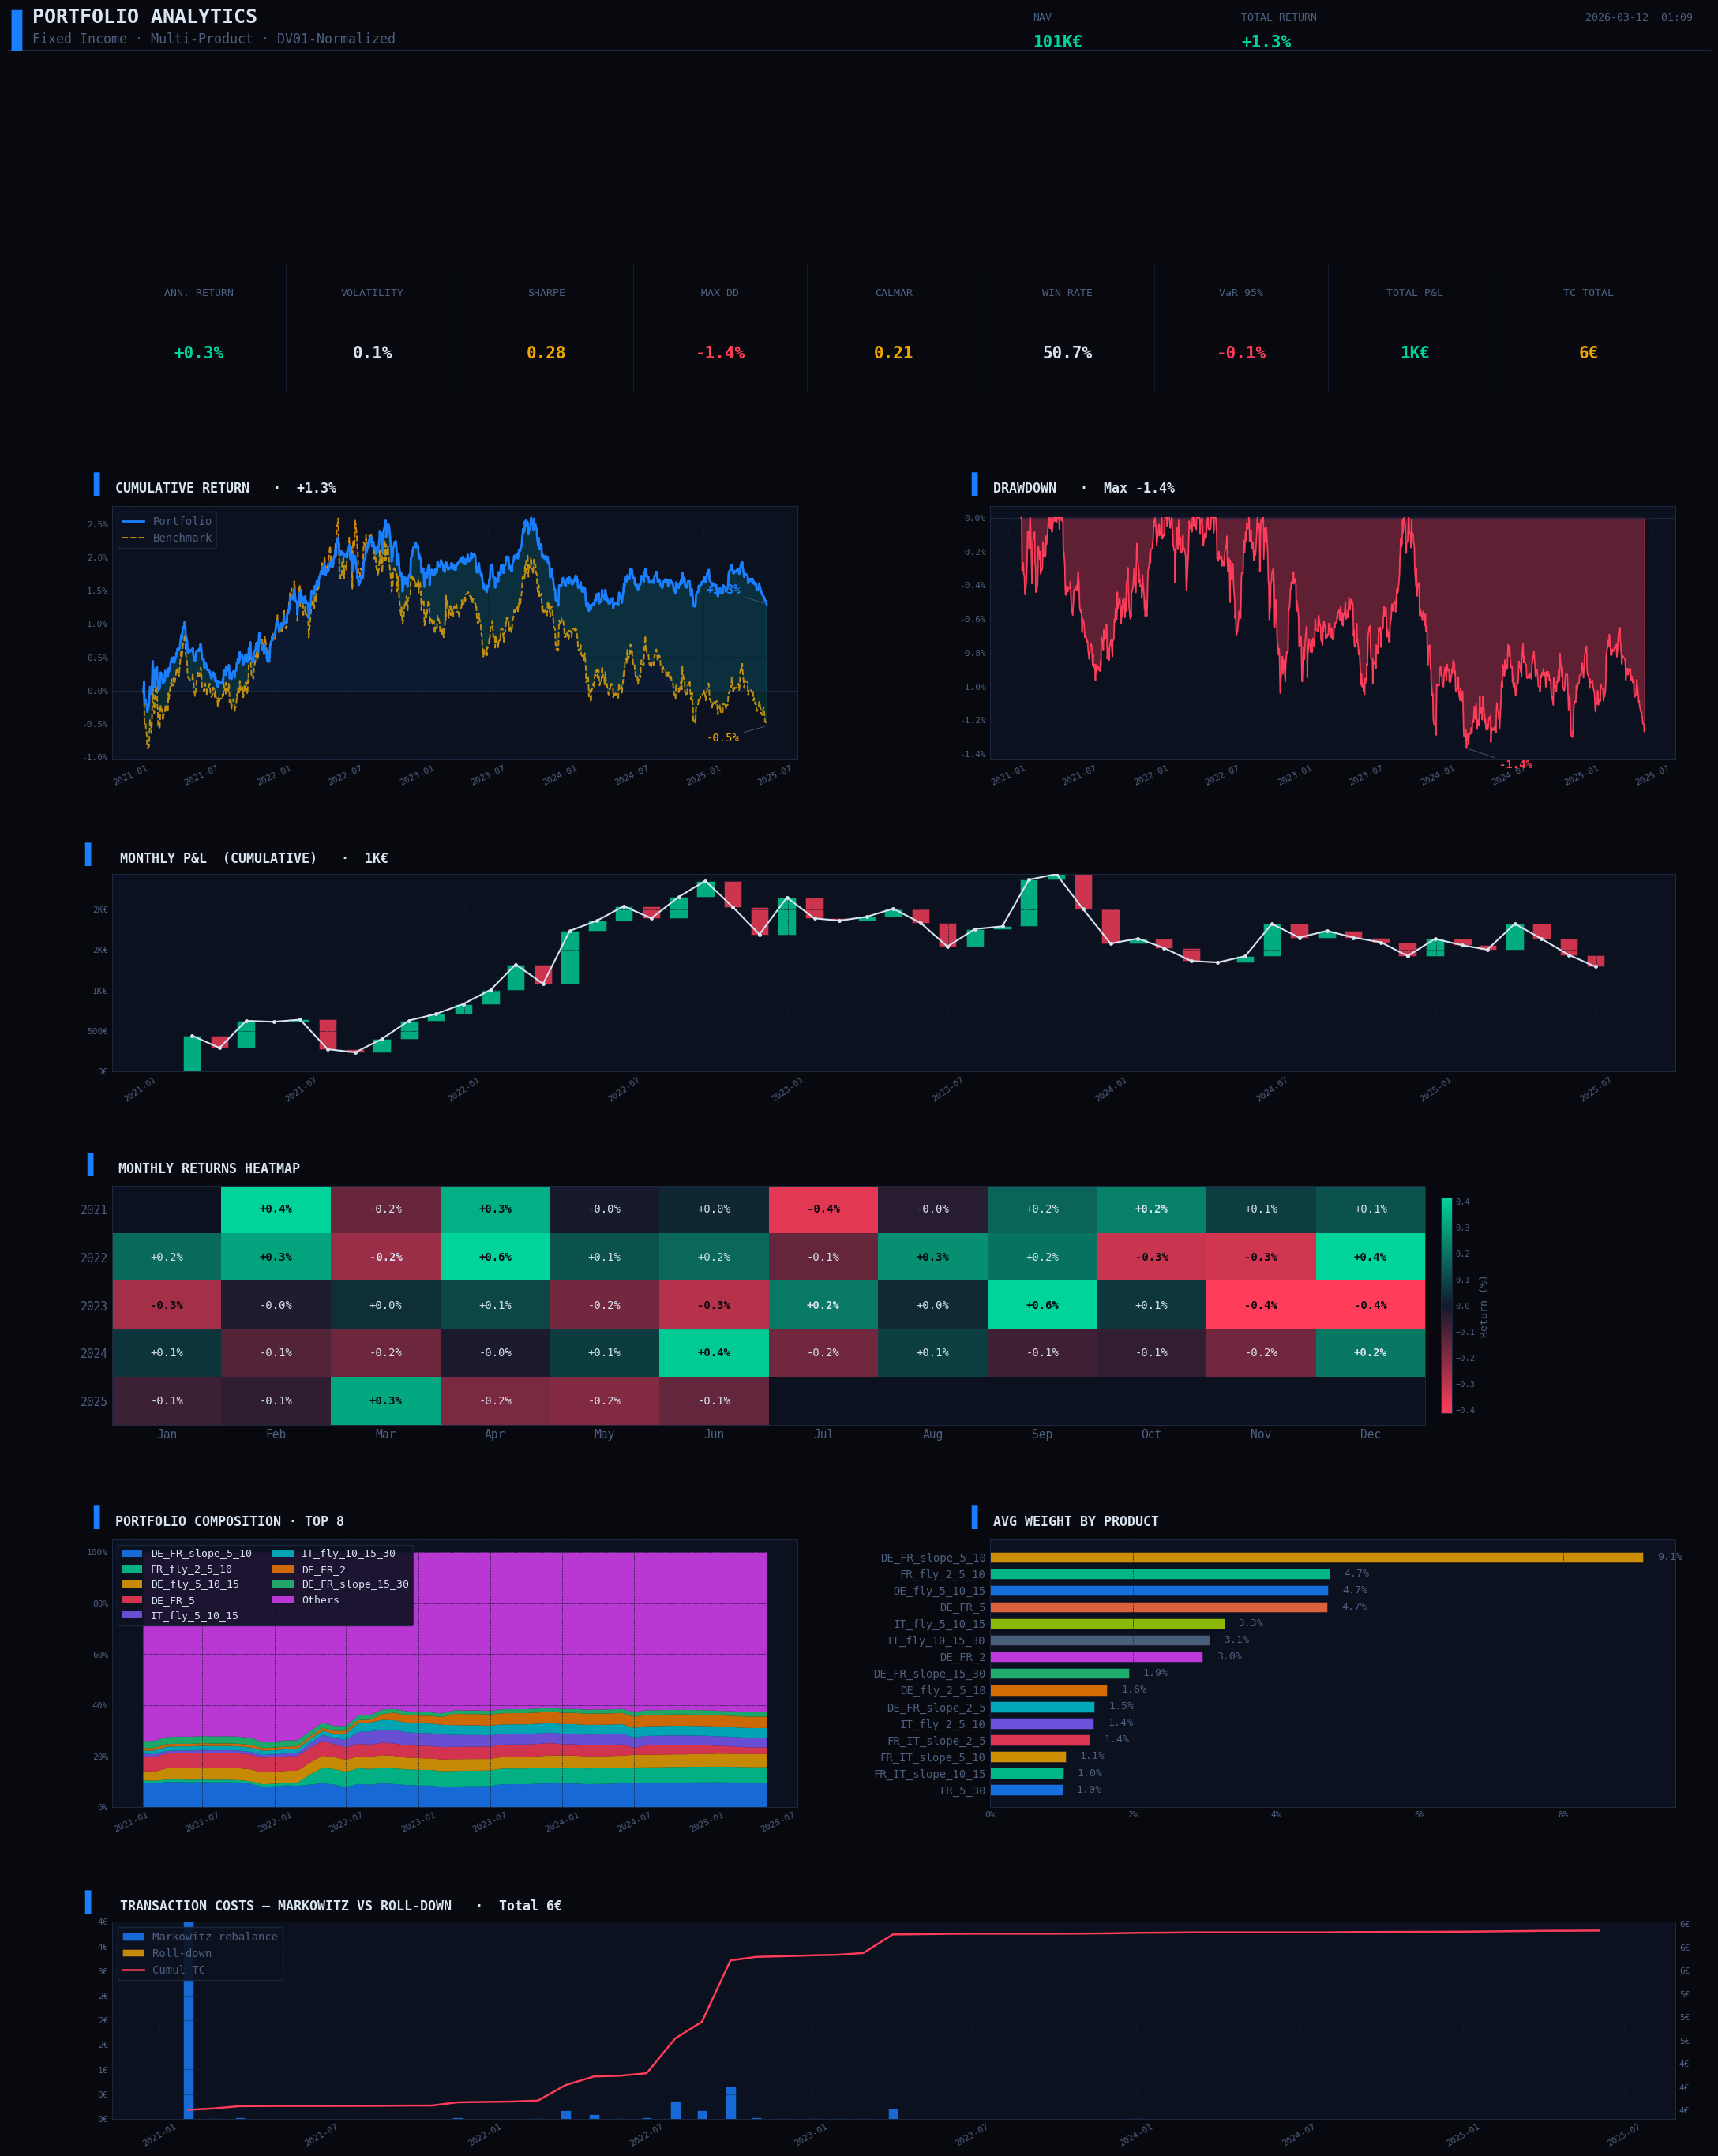

In [101]:
start_date = "2021-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data=long,
    start_date="2021-01-01",
    end_date="2025-06-10",
    rebalance_freq="ME",
    long_only=True,
    lamb=0.45, # 0.45
    span=15, # 15
    tc_gamma=140000  #140000 intensité des coûts dans l’optimisation
    #initial_weights= df_weights["weight"]
)



tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(ts_portfolio=tspf)
#viz.plot_dashboard(save_path="dashboard.png", dpi=100)

fig = viz.plot_dashboard()





In [96]:
from joblib import Parallel, delayed
import itertools
import numpy as np
import pandas as pd


param_grid = {
    "lamb": np.linspace(0.3, 0.7, 2),
    "span": [15],
    "tc_gamma": np.linspace(120000, 140000, 2),
}

combinations = list(itertools.product(
    param_grid["lamb"],
    param_grid["span"],
    param_grid["tc_gamma"],
))

print(f"{len(combinations)} combinaisons à tester...\n")


def run_backtest(params):

    lamb, span, tc_gamma = params

    try:
        tspf = TimeSeriesPortfolio(
            data=long,
            start_date="2021-01-01",
            end_date="2025-06-10",
            rebalance_freq="ME",
            long_only=False,
            lamb=lamb,
            span=span,
            tc_gamma=tc_gamma,
            dv01_ref=dv01_ref,
        )

        tspf.generate_portfolios()

        m = tspf.metrics

        sharpe = m.get("sharpe", np.nan)
        ann_ret = m.get("mean_return", np.nan) * 252
        ann_vol = m.get("volatility", np.nan) * np.sqrt(252)
        max_dd = m.get("max_drawdown", np.nan)
        tc_total = m.get("transaction_costs", pd.Series()).sum()

        return {
            "lamb": lamb,
            "span": span,
            "tc_gamma": tc_gamma,
            "sharpe": sharpe,
            "ann_ret": ann_ret,
            "ann_vol": ann_vol,
            "max_dd": max_dd,
            "tc_total": tc_total,
        }

    except Exception as e:
        return {
            "lamb": lamb,
            "span": span,
            "tc_gamma": tc_gamma,
            "error": str(e),
        }


# ── exécution parallèle ─────────────────────────────────────

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_backtest)(params) for params in combinations
)

df_results = pd.DataFrame(results)#.sort_values("sharpe", ascending=False)

4 combinaisons à tester...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   36.5s
[Parallel(n_jobs=-1)]: Done   2 out of   4 | elapsed:   36.7s remaining:   36.7s
[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:   36.8s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:   36.8s finished


In [98]:
df_results = pd.DataFrame(results).sort_values("sharpe", ascending=False)
df_results.head(10)

,lamb,span,tc_gamma,sharpe,ann_ret,ann_vol,max_dd,tc_total
2,0.7,15,120000.0,0.638666,0.005594,0.008759,-0.010377,8.158107
3,0.7,15,140000.0,0.631136,0.005625,0.008912,-0.010909,7.973119
0,0.3,15,120000.0,0.606271,0.005668,0.009349,-0.011691,7.619376
1,0.3,15,140000.0,0.601060,0.005610,0.009334,-0.011468,7.158990


In [83]:
df_results = pd.DataFrame(results).sort_values("ann_ret", ascending=False)
df_results.head(10)

,lamb,span,tc_gamma,sharpe,ann_ret,ann_vol,max_dd,tc_total
3,0.005,15,10000.0,0.062775,0.033674,0.536416,-0.819522,429.757826
0,0.001,15,5000.0,-0.276274,-4.076546,14.755438,-3.664947,1324.791135
2,0.005,15,5000.0,-0.652930,-13.744758,21.050902,-1.140145,638.798813
1,0.001,15,10000.0,-0.384729,-14.484603,37.648801,-2.335939,1019.657061
